In [7]:
from typing import Union 
def square(x:Union[int,float])  -> float:
       return x*x 
x=5 
x=1.234 
#x="i am a string"
y=square(x)
print(y)

1.522756


In [8]:
from typing import Optional 

def nice_message(name:Optional[str]=None) -> str:
    if name is None:
        return "Hello, World!"
    else:
        return f"Hello, {name}!"


        ## here number can be string or not 

In [9]:
from typing import Any 

def print_value(x:Any):
       print(x)
print_value('I pretend to be a Batman in the shower sometimes')

I pretend to be a Batman in the shower sometimes


In [10]:
square= lambda x : x*x 
square(5)

25

In [11]:
num=[1,2,3,4]
squares=list(map(lambda x: x*x,num))
print(squares)

[1, 4, 9, 16]


In [12]:
from typing import Dict, TypedDict
from langgraph.graph import StateGraph 

lets create a graph 

agent state >> shared data structure 


In [13]:
class AgentState(TypedDict):
       message: str 


def greeting_node(state:AgentState)-> AgentState:
       """"simple node that adds greeting message """
       state['message']='Hey'+state['message']+",how is your day going ? "
       return state


In [14]:
graph=StateGraph(AgentState)
graph.add_node("greeter",greeting_node)
graph.set_entry_point("greeter")
graph.set_finish_point('greeter')
app = graph.compile()

In [15]:
!pip install Ipython

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


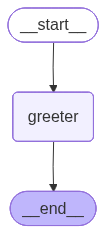

In [16]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [17]:
result = app.invoke({"message":"Bob"})

In [18]:
result["message"]

'HeyBob,how is your day going ? '

second graph 

In [23]:
from typing import TypedDict, List
from langgraph.graph import StateGraph 

In [24]:
class AgentState(TypedDict):
       values :List[int]
       name :str 
       result : str 



In [25]:
def process_values(state:AgentState) -> AgentState:
       """This function handles multiple values."""

       values = state.get('values', [])
       name = state.get('name', 'Unknown')
       return {'result': f"Hello {name}, the sum of your values is {sum(values)}"}

In [26]:
graph=StateGraph(AgentState)
graph.add_node("processor",process_values)

In [26]:
graph=StateGraph(AgentState)
graph.add_node("processor",process_values)
graph.set_entry_point("processor")
graph.set_finish_point("processor")
app=graph.compile()

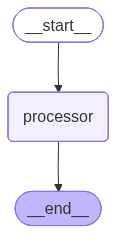

In [33]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [38]:
result=app.invoke({"values": [1, 2, 3], "name": "Alice"})

In [39]:
# Clean fixed processor graph cell
from typing import TypedDict, List
from langgraph.graph import StateGraph

class AgentState(TypedDict):
    values: List[int]
    name: str
    result: str

def process_values(state: AgentState) -> AgentState:
    values = state.get("values", [])
    name = state.get("name", "Unknown")
    return {"result": f"Hello {name}, the sum of your values is {sum(values)}"}

graph = StateGraph(AgentState)
graph.add_node("processor", process_values)
graph.set_entry_point("processor")
graph.set_finish_point("processor")
app = graph.compile()

result = app.invoke({"values": [1, 2, 3], "name": "Alice"})
result

{'values': [1, 2, 3],
 'name': 'Alice',
 'result': 'Hello Alice, the sum of your values is 6'}

In [40]:
print(result["result"])  # Output: Hello Alice, the sum of your values is 6

Hello Alice, the sum of your values is 6


just access results 

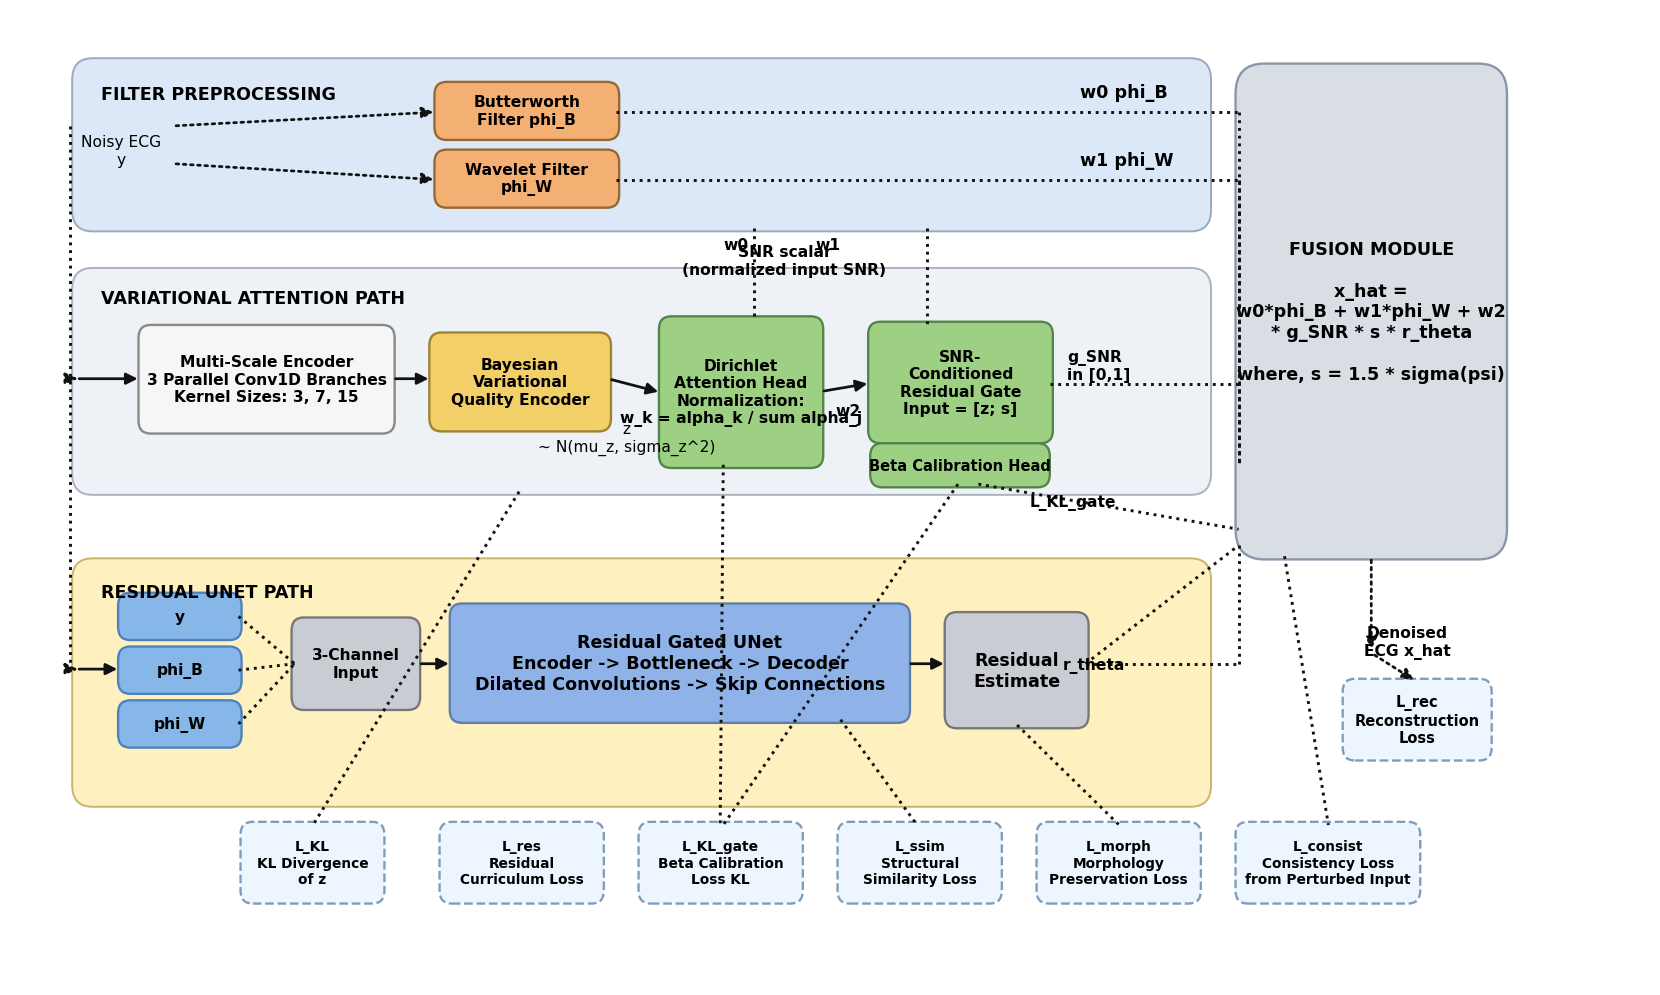

In [40]:
# Architecture diagram cell
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(figsize=(16, 9), dpi=140)
ax.set_xlim(0, 16)
ax.set_ylim(0, 9)
ax.axis("off")

COLORS = {
    "filter": "#dce8f7",
    "var": "#eef2f6",
    "res": "#fff0bf",
    "fusion": "#d9dde4",
    "blue": "#8fb2e8",
    "green": "#9ed083",
    "orange": "#f4b073",
    "yellow": "#f3cf68",
    "gray": "#c9cdd3",
    "loss": "#edf6ff",
}

def rounded_box(x, y, w, h, text, fc="white", ec="#667", lw=1.2, fontsize=9,
                weight="normal", ls="solid", radius=0.12, z=2):
    patch = FancyBboxPatch(
        (x, y), w, h,
        boxstyle=f"round,pad=0.03,rounding_size={radius}",
        facecolor=fc,
        edgecolor=ec,
        linewidth=lw,
        linestyle=ls,
        zorder=z,
    )
    ax.add_patch(patch)
    ax.text(
        x + w / 2, y + h / 2, text,
        ha="center", va="center", fontsize=fontsize,
        fontweight=weight, wrap=True, zorder=z + 1,
    )
    return patch

def label(x, y, text, fontsize=9, weight="bold", ha="left"):
    ax.text(x, y, text, fontsize=fontsize, fontweight=weight, ha=ha, va="center", zorder=5)

def arrow(x1, y1, x2, y2, style="solid", color="#111", lw=1.4, ms=12, z=4):
    arr = FancyArrowPatch(
        (x1, y1), (x2, y2),
        arrowstyle="-|>", mutation_scale=ms,
        linewidth=lw, color=color, linestyle=style,
        shrinkA=2, shrinkB=2, zorder=z,
    )
    ax.add_patch(arr)
    return arr

def line(x1, y1, x2, y2, style="dotted", color="#111", lw=1.5, z=3):
    ax.plot([x1, x2], [y1, y2], linestyle=style, color=color, linewidth=lw, zorder=z)

# Outer modules
rounded_box(0.6, 7.0, 11.1, 1.55, "", fc=COLORS["filter"], ec="#9aa9bc", lw=1.0, radius=0.2, z=0)
label(0.85, 8.25, "FILTER PREPROCESSING")
rounded_box(0.6, 4.55, 11.1, 2.05, "", fc=COLORS["var"], ec="#aab4c0", lw=1.0, radius=0.2, z=0)
label(0.85, 6.35, "VARIATIONAL ATTENTION PATH")
rounded_box(0.6, 1.65, 11.1, 2.25, "", fc=COLORS["res"], ec="#c9b567", lw=1.0, radius=0.2, z=0)
label(0.85, 3.62, "RESIDUAL UNET PATH")
rounded_box(12.0, 3.95, 2.6, 4.55, "FUSION MODULE\n\n"
            "x_hat =\nw0*phi_B + w1*phi_W + w2\n"
            "* g_SNR * s * r_theta\n\n"
            "where, s = 1.5 * sigma(psi)",
            fc=COLORS["fusion"], ec="#8995a8", lw=1.2, fontsize=9, weight="bold", radius=0.28)

# Filter preprocessing
label(1.05, 7.72, "Noisy ECG\ny", fontsize=8, weight="normal", ha="center")
rounded_box(4.15, 7.85, 1.75, 0.48, "Butterworth\nFilter phi_B", fc=COLORS["orange"], ec="#956733", fontsize=8, weight="bold")
rounded_box(4.15, 7.22, 1.75, 0.48, "Wavelet Filter\nphi_W", fc=COLORS["orange"], ec="#956733", fontsize=8, weight="bold")
arrow(1.55, 7.95, 4.15, 8.08, style="dotted")
arrow(1.55, 7.60, 4.15, 7.45, style="dotted")
line(5.90, 8.08, 12.0, 8.08, "dotted")
line(5.90, 7.45, 12.0, 7.45, "dotted")
label(10.45, 8.27, "w0 phi_B", fontsize=9)
label(10.45, 7.63, "w1 phi_W", fontsize=9)

# Variational attention path
rounded_box(1.25, 5.12, 2.45, 0.95, "Multi-Scale Encoder\n3 Parallel Conv1D Branches\nKernel Sizes: 3, 7, 15", fc="#f6f6f6", ec="#888", fontsize=8, weight="bold")
rounded_box(4.1, 5.14, 1.72, 0.86, "Bayesian\nVariational\nQuality Encoder", fc=COLORS["yellow"], ec="#9c8332", fontsize=8, weight="bold")
rounded_box(6.35, 4.80, 1.55, 1.35, "Dirichlet\nAttention Head\nNormalization:\nw_k = alpha_k / sum alpha_j", fc=COLORS["green"], ec="#52844c", fontsize=8, weight="bold")
rounded_box(8.40, 5.03, 1.75, 1.07, "SNR-\nConditioned\nResidual Gate\nInput = [z; s]", fc=COLORS["green"], ec="#52844c", fontsize=8, weight="bold")
rounded_box(8.42, 4.62, 1.7, 0.35, "Beta Calibration Head", fc=COLORS["green"], ec="#52844c", fontsize=7.5, weight="bold")
arrow(0.6, 5.60, 1.25, 5.60)
arrow(3.70, 5.60, 4.10, 5.60)
arrow(5.82, 5.60, 6.35, 5.47)
arrow(7.90, 5.48, 8.40, 5.56)
line(10.15, 5.55, 12.0, 5.55, "dotted")
label(10.32, 5.72, "g_SNR\nin [0,1]", fontsize=8, weight="bold")
label(6.0, 5.05, "z\n~ N(mu_z, sigma_z^2)", fontsize=8, weight="normal", ha="center")
label(7.55, 6.70, "SNR scalar\n(normalized input SNR)", fontsize=8, weight="bold", ha="center")
line(7.25, 7.0, 7.25, 6.15, "dotted")
line(8.95, 7.0, 8.95, 6.10, "dotted")
label(6.95, 6.85, "w0", fontsize=8)
label(7.85, 6.85, "w1", fontsize=8)
label(8.05, 5.30, "w2", fontsize=8)
line(9.45, 4.62, 12.0, 4.20, "dotted")
label(9.95, 4.45, "L_KL_gate", fontsize=8, weight="bold")

# Residual UNet path
rounded_box(1.05, 3.20, 1.15, 0.38, "y", fc="#87b7e9", ec="#4c83bd", fontsize=8, weight="bold")
rounded_box(1.05, 2.70, 1.15, 0.38, "phi_B", fc="#87b7e9", ec="#4c83bd", fontsize=8, weight="bold")
rounded_box(1.05, 2.20, 1.15, 0.38, "phi_W", fc="#87b7e9", ec="#4c83bd", fontsize=8, weight="bold")
rounded_box(2.75, 2.55, 1.20, 0.80, "3-Channel\nInput", fc=COLORS["gray"], ec="#777", fontsize=8, weight="bold")
rounded_box(4.30, 2.43, 4.45, 1.05, "Residual Gated UNet\nEncoder -> Bottleneck -> Decoder\nDilated Convolutions -> Skip Connections", fc=COLORS["blue"], ec="#5f7fa9", fontsize=9, weight="bold")
rounded_box(9.15, 2.38, 1.35, 1.02, "Residual\nEstimate", fc=COLORS["gray"], ec="#777", fontsize=9, weight="bold")
label(10.28, 2.94, "r_theta", fontsize=8, weight="bold")
arrow(0.6, 2.90, 1.05, 2.90)
line(2.20, 3.39, 2.75, 2.95, "dotted")
line(2.20, 2.89, 2.75, 2.95, "dotted")
line(2.20, 2.39, 2.75, 2.95, "dotted")
arrow(3.95, 2.95, 4.30, 2.95)
arrow(8.75, 2.95, 9.15, 2.95)
line(10.50, 2.95, 12.0, 4.05, "dotted")

# Fusion outputs and losses
arrow(13.30, 3.95, 13.30, 3.05, style="dotted")
label(13.65, 3.15, "Denoised\nECG x_hat", fontsize=8, weight="bold", ha="center")
rounded_box(13.05, 2.08, 1.40, 0.70, "L_rec\nReconstruction\nLoss", fc=COLORS["loss"], ec="#7e9dbb", fontsize=7.5, weight="bold", ls="dashed")
arrow(13.30, 3.05, 13.75, 2.78, style="dotted")

losses = [
    (2.25, 0.75, 1.35, "L_KL\nKL Divergence\nof z"),
    (4.20, 0.75, 1.55, "L_res\nResidual\nCurriculum Loss"),
    (6.15, 0.75, 1.55, "L_KL_gate\nBeta Calibration\nLoss KL"),
    (8.10, 0.75, 1.55, "L_ssim\nStructural\nSimilarity Loss"),
    (10.05, 0.75, 1.55, "L_morph\nMorphology\nPreservation Loss"),
    (12.00, 0.75, 1.75, "L_consist\nConsistency Loss\nfrom Perturbed Input"),
]
for x, y, w, txt in losses:
    rounded_box(x, y, w, 0.70, txt, fc=COLORS["loss"], ec="#7e9dbb", fontsize=7.1, weight="bold", ls="dashed")

# Loss connectors
line(4.95, 4.55, 2.93, 1.45, "dotted")
line(6.95, 4.80, 6.92, 1.45, "dotted")
line(9.25, 4.62, 6.95, 1.45, "dotted")
line(8.10, 2.43, 8.85, 1.45, "dotted")
line(9.83, 2.38, 10.83, 1.45, "dotted")
line(12.45, 3.95, 12.88, 1.45, "dotted")

# Input split and fusion dotted routes
line(0.55, 7.95, 0.55, 2.90, "dotted")
arrow(0.55, 5.60, 0.62, 5.60, style="dotted")
arrow(0.55, 2.90, 0.62, 2.90, style="dotted")
line(12.0, 8.08, 12.0, 4.8, "dotted")
line(12.0, 7.45, 12.0, 4.8, "dotted")
line(10.50, 2.95, 12.0, 2.95, "dotted")
line(12.0, 2.95, 12.0, 4.05, "dotted")

plt.tight_layout()
plt.show()